# 1. Phân tích quãng đường

--- KHỐI 1: PHÂN TÍCH QUÃNG ĐƯỜNG (TRIP DISTANCE) ---
Đã tải thành công 3,499,217 dòng dữ liệu.

- CÓ NHIỀU RIDERS ĐI GẦN KHÔNG? -> Có rất nhiều! Tỷ lệ cuốc xe ĐI RẤT GẦN (<= 2 miles) chiếm tới 52.5%
- CÓ RIDERS ĐI RẤT XA KHÔNG? -> Có nhưng hiếm! Tỷ lệ cuốc xe ĐI RẤT XA (> 10 miles) chỉ chiếm 7.7%



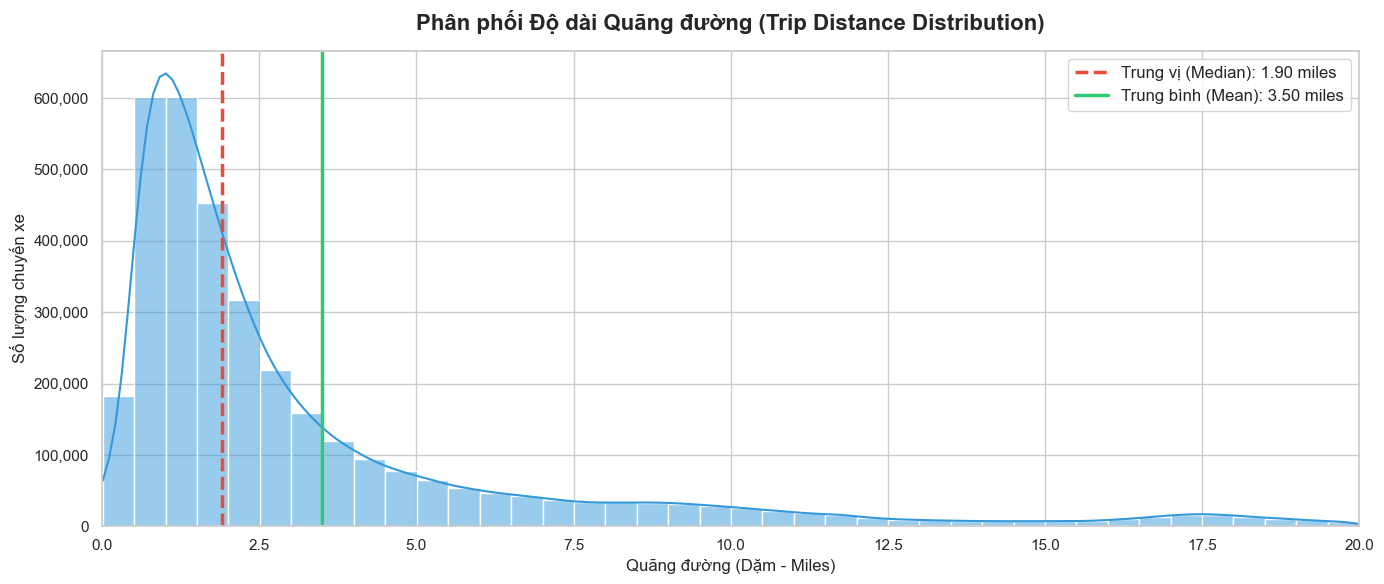

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tùy chỉnh giao diện biểu đồ cho chuyên nghiệp
sns.set_theme(style="whitegrid")

print("--- KHỐI 1: PHÂN TÍCH QUÃNG ĐƯỜNG (TRIP DISTANCE) ---")

# 1. Tải dữ liệu
clean_data_path = r'../../data/yellow_tripdata_2026-01_CLEANED.parquet'
df = pd.read_parquet(clean_data_path)
print(f"Đã tải thành công {len(df):,} dòng dữ liệu.\n")

# Lọc bỏ các giá trị nhiễu (quãng đường <= 0)
df = df[df['trip_distance'] > 0]

# 2. Trả lời trực tiếp câu hỏi nghiên cứu (Business Question)
short_trips = len(df[df['trip_distance'] <= 2]) / len(df) * 100
long_trips = len(df[df['trip_distance'] > 10]) / len(df) * 100

print(f"- CÓ NHIỀU RIDERS ĐI GẦN KHÔNG? -> Có rất nhiều! Tỷ lệ cuốc xe ĐI RẤT GẦN (<= 2 miles) chiếm tới {short_trips:.1f}%")
print(f"- CÓ RIDERS ĐI RẤT XA KHÔNG? -> Có nhưng hiếm! Tỷ lệ cuốc xe ĐI RẤT XA (> 10 miles) chỉ chiếm {long_trips:.1f}%\n")

# 3. Vẽ biểu đồ phân phối Quãng đường (Giới hạn trục X dưới 20 miles để không bị bóp méo hình dạng)
plt.figure(figsize=(14, 6))
sns.histplot(data=df[df['trip_distance'] <= 20], x='trip_distance', bins=40, color='#3498DB', kde=True)

# Thêm các đường chuẩn (Trung vị và Trung bình)
median_dist = df['trip_distance'].median()
mean_dist = df['trip_distance'].mean()

plt.axvline(median_dist, color='#E74C3C', linestyle='--', linewidth=2.5, label=f'Trung vị (Median): {median_dist:.2f} miles')
plt.axvline(mean_dist, color='#2ECC71', linestyle='-', linewidth=2.5, label=f'Trung bình (Mean): {mean_dist:.2f} miles')

plt.title('Phân phối Độ dài Quãng đường (Trip Distance Distribution)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quãng đường (Dặm - Miles)', fontsize=12)
plt.ylabel('Số lượng chuyến xe', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xlim(0, 20)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



> **📝 Góc nhìn Tiền đề Phân khúc (Segmentation Insights):**
> * **Bản chất của dịch vụ:** Đường phân phối bị lệch phải cực kỳ nặng (Right-skewed). Khoảng 50% số cuốc xe (Trung vị/Median) chỉ di chuyển trong phạm vi dưới **1.9 dặm (khoảng 3km)** - một cự ly rất ngắn! Điều này xác nhận lại phát hiện ở Task 3: Taxi vàng chủ yếu phục vụ nhu cầu di chuyển nội bộ khu phố (Intra-zone).
> * **Tệp khách "Đi rất xa" (Long-haul Riders):** Dù tỷ lệ cuốc xe > 10 miles rất nhỏ, nhưng nếu bạn nhìn kỹ vào cuối biểu đồ, có một "cục u" nhỏ nổi lên ở mốc **17-18 miles**. Đây không phải lỗi dữ liệu, mà chính xác là **tệp khách hàng đi Sân bay JFK**! Khách đi Sân bay là một phân khúc (Segment) độc lập, có hình dáng đồ thị tách biệt hoàn toàn so với khách nội đô.


# 2. Phân tích thời lượng chuyến đi


--- KHỐI 2: PHÂN TÍCH THỜI LƯỢNG (TRIP DURATION) ---


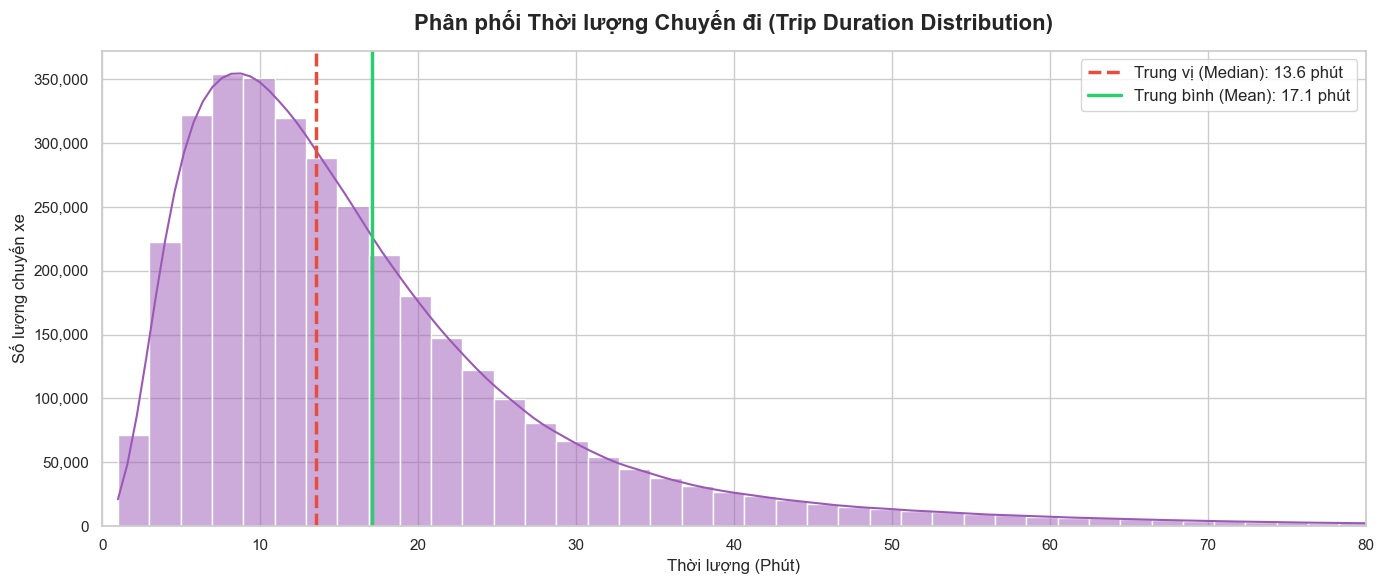

- CÓ NHIỀU RIDERS ĐI GẦN KHÔNG? -> Rất nhiều! Khoảng 55.9% khách hàng rời khỏi xe chỉ trong vòng 15 phút hoặc ít hơn.
- CÓ RIDERS ĐI RẤT XA KHÔNG? -> Rất hiếm! Chỉ có 1.8% khách hàng ngồi trên xe quá 1 tiếng đồng hồ.


In [2]:
print("--- KHỐI 2: PHÂN TÍCH THỜI LƯỢNG (TRIP DURATION) ---")

# 1. Tính toán thời lượng (Phút) từ datetime
df['trip_duration_mins'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Lọc các giá trị hợp lý (Bỏ các cuốc dưới 1 phút hoặc cuốc bị kẹt đồng hồ > 2 tiếng)
valid_duration = df[(df['trip_duration_mins'] >= 1) & (df['trip_duration_mins'] <= 120)]

# 2. Vẽ biểu đồ phân phối Thời lượng
plt.figure(figsize=(14, 6))
sns.histplot(data=valid_duration, x='trip_duration_mins', bins=60, color='#9B59B6', kde=True)

# Thêm đường Median và Mean
median_dur = valid_duration['trip_duration_mins'].median()
mean_dur = valid_duration['trip_duration_mins'].mean()

plt.axvline(median_dur, color='#E74C3C', linestyle='--', linewidth=2.5, label=f'Trung vị (Median): {median_dur:.1f} phút')
plt.axvline(mean_dur, color='#2ECC71', linestyle='-', linewidth=2.5, label=f'Trung bình (Mean): {mean_dur:.1f} phút')

plt.title('Phân phối Thời lượng Chuyến đi (Trip Duration Distribution)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Thời lượng (Phút)', fontsize=12)
plt.ylabel('Số lượng chuyến xe', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xlim(0, 80)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Trả lời câu hỏi nghiên cứu (Business Question)
short_time = len(valid_duration[valid_duration['trip_duration_mins'] <= 15]) / len(valid_duration) * 100
long_time = len(valid_duration[valid_duration['trip_duration_mins'] > 60]) / len(valid_duration) * 100

print(f"- CÓ NHIỀU RIDERS ĐI GẦN KHÔNG? -> Rất nhiều! Khoảng {short_time:.1f}% khách hàng rời khỏi xe chỉ trong vòng 15 phút hoặc ít hơn.")
print(f"- CÓ RIDERS ĐI RẤT XA KHÔNG? -> Rất hiếm! Chỉ có {long_time:.1f}% khách hàng ngồi trên xe quá 1 tiếng đồng hồ.")


> **📝 Góc nhìn Tiền đề Phân khúc (Segmentation Insights):**
> * **Cuốc xe cực ngắn là chủ đạo:** Trung vị (Median) chỉ **13.6 phút** - hơn một nửa số khách hàng xuống xe trước khi bài nhạc đầu tiên kết thúc! Đây là bằng chứng rõ ràng nhất cho hành vi di chuyển ngắn hạn (Short-trip behavior) của người dùng Taxi vàng.
> * **Trung bình bị kéo lên bởi "Đuôi dài":** Trung bình (Mean) là **17.1 phút** - cao hơn Trung vị tới 3.5 phút. Sự chênh lệch này cho thấy một tệp nhỏ khách hàng đi rất xa (các cuốc sân bay, cuốc liên quận) đang kéo lên con số trung bình và làm nó mất tính đại diện. Đây là lý do **Median luôn đáng tin cậy hơn Mean** khi dữ liệu bị lệch.
> * **Tiền đề Phân khúc (Feature for Segmentation):** Cột `trip_duration_mins` vừa tạo ra sẽ là một **Feature cực kỳ mạnh** để phân chia khách hàng thành: Nhóm đi ngắn (< 15 phút), Nhóm đi trung bình (15-30 phút) và Nhóm đi dài (> 30 phút).


# 3. Phân tích cước phí


--- KHỐI 3: PHÂN TÍCH CƯỚC PHÍ (FARE ANALYSIS) ---
📊 Các chỉ số Cước phí cốt lõi:
   - Average Fare (Trung bình):         $21.10
   - Median Fare (Trung vị):             $15.60
   - Avg Fare per Mile (Giá/dặm TB):     $8.43/mile
   - Median Fare per Mile (Giá/dặm TV):  $7.50/mile



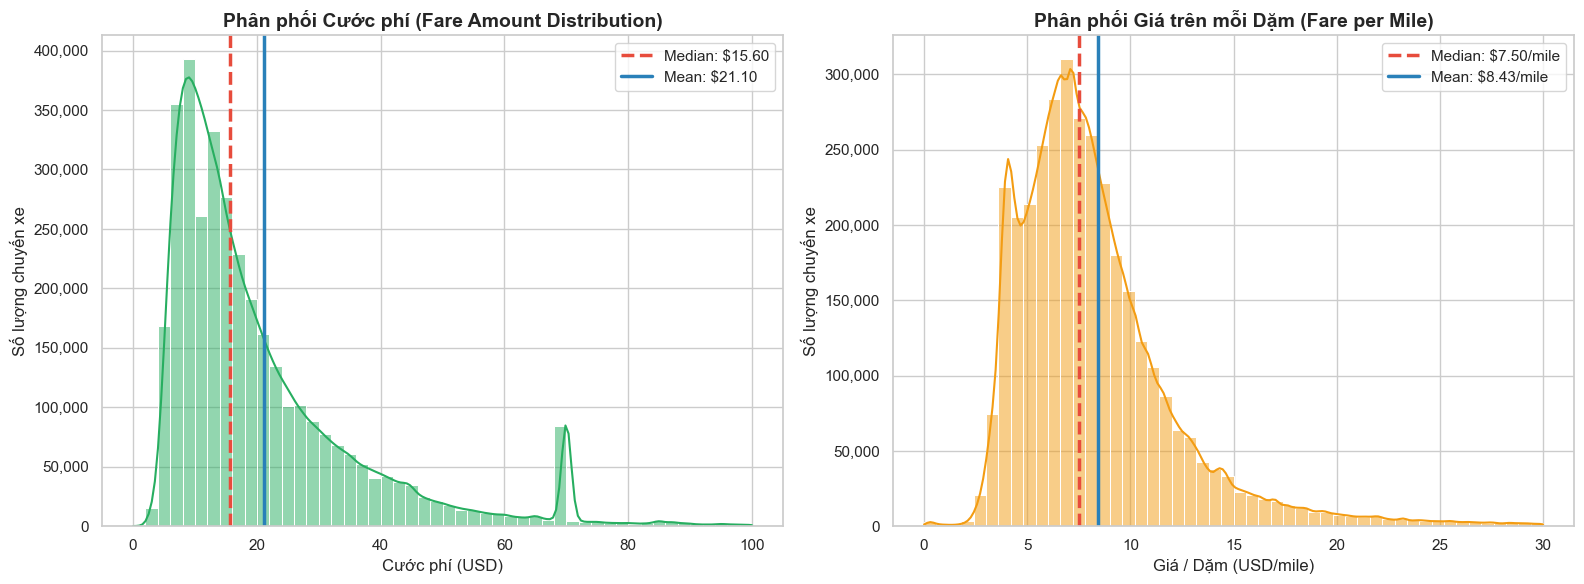

In [3]:
print("--- KHỐI 3: PHÂN TÍCH CƯỚC PHÍ (FARE ANALYSIS) ---")

# 1. Lọc bỏ giá trị âm hoặc không hợp lý
valid_fare = df[df['fare_amount'] > 0].copy()

# 2. Tính 3 chỉ số cốt lõi (Core Metrics)
avg_fare = valid_fare['fare_amount'].mean()
median_fare = valid_fare['fare_amount'].median()
valid_fare['fare_per_mile'] = valid_fare['fare_amount'] / valid_fare['trip_distance']

# Lọc fare_per_mile hợp lý (bỏ các cuốc có giá/mile cực cao do chia cho quãng đường gần 0)
valid_fare_pm = valid_fare[valid_fare['fare_per_mile'] < 50]
avg_fare_per_mile = valid_fare_pm['fare_per_mile'].mean()
median_fare_per_mile = valid_fare_pm['fare_per_mile'].median()

print(f"📊 Các chỉ số Cước phí cốt lõi:")
print(f"   - Average Fare (Trung bình):         ${avg_fare:.2f}")
print(f"   - Median Fare (Trung vị):             ${median_fare:.2f}")
print(f"   - Avg Fare per Mile (Giá/dặm TB):     ${avg_fare_per_mile:.2f}/mile")
print(f"   - Median Fare per Mile (Giá/dặm TV):  ${median_fare_per_mile:.2f}/mile\n")

# 3. Vẽ 2 biểu đồ song song: Phân phối Fare và Fare per Mile
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ trái: Phân phối Fare Amount (giới hạn 100 để tập trung vào phần lớn dữ liệu)
sns.histplot(data=valid_fare[valid_fare['fare_amount'] <= 100], x='fare_amount', bins=50, 
             color='#27AE60', kde=True, ax=ax[0])
ax[0].axvline(median_fare, color='#E74C3C', linestyle='--', linewidth=2.5, label=f'Median: ${median_fare:.2f}')
ax[0].axvline(avg_fare, color='#2980B9', linestyle='-', linewidth=2.5, label=f'Mean: ${avg_fare:.2f}')
ax[0].set_title('Phân phối Cước phí (Fare Amount Distribution)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Cước phí (USD)', fontsize=12)
ax[0].set_ylabel('Số lượng chuyến xe', fontsize=12)
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax[0].legend(fontsize=11)

# Biểu đồ phải: Phân phối Fare per Mile (Giá / dặm)
sns.histplot(data=valid_fare_pm[valid_fare_pm['fare_per_mile'] <= 30], x='fare_per_mile', bins=50, 
             color='#F39C12', kde=True, ax=ax[1])
ax[1].axvline(median_fare_per_mile, color='#E74C3C', linestyle='--', linewidth=2.5, label=f'Median: ${median_fare_per_mile:.2f}/mile')
ax[1].axvline(avg_fare_per_mile, color='#2980B9', linestyle='-', linewidth=2.5, label=f'Mean: ${avg_fare_per_mile:.2f}/mile')
ax[1].set_title('Phân phối Giá trên mỗi Dặm (Fare per Mile)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Giá / Dặm (USD/mile)', fontsize=12)
ax[1].set_ylabel('Số lượng chuyến xe', fontsize=12)
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()


> **📝 Góc nhìn Tiền đề Phân khúc (Segmentation Insights):**
>
> **1. Phân phối Cước phí có 2 đỉnh (Bimodal Distribution - Phát hiện bất ngờ!):**
> Nhìn vào biểu đồ bên trái, bạn có thấy có **2 ngọn núi** không? Ngọn núi lớn ở mức ~$10-15 là các cuốc xe nội đô ngắn thông thường (Median: $15.60). Nhưng còn có một **ngọn núi nhỏ thứ 2 nằm ở mức ~$65-70** - đây chính xác là **Giá cố định (Flat Rate) của tuyến JFK Airport!** NYC TLC quy định cuốc xe JFK từ/đến Manhattan luôn có giá cố định là $70. Biểu đồ thống kê đã tự động "nhìn thấy" và vẽ ra luồng khách sân bay tách biệt hoàn toàn!
>
> **2. Fare per Mile (Giá/Dặm) - Thước đo "Lợi nhuận" thực sự:**
> Tỷ lệ Median là **$7.50/mile** (khoảng 120,000 VND/1.6km). Đây chính là "Đơn giá cơ bản" của Taxi vàng ở NYC. Cuốc xe nào có `fare_per_mile` cao hơn $7.50 nghĩa là khách phải trả nhiều hơn mức trung bình (ví dụ: cuốc quá ngắn, phải chịu phí cố định ban đầu cao) - đây là tệp **"Khách đắt giá"** cho tài xế.


# 4. Phân tích văn hóa tiền bo và thanh toán



--- KHỐI 4 (BONUS): VĂN HÓA TIỀN BO & THANH TOÁN (TIPPING BEHAVIOR) ---
📊 Thống kê Tiền Bo (chỉ tính trên khách Quẹt thẻ):
   - Tỷ lệ khách CÓ Bo:        90.6%
   - Tỷ lệ khách KHÔNG Bo:     9.4%
   - Mức Bo trung bình (khi có Bo): 27.6% trên giá cước



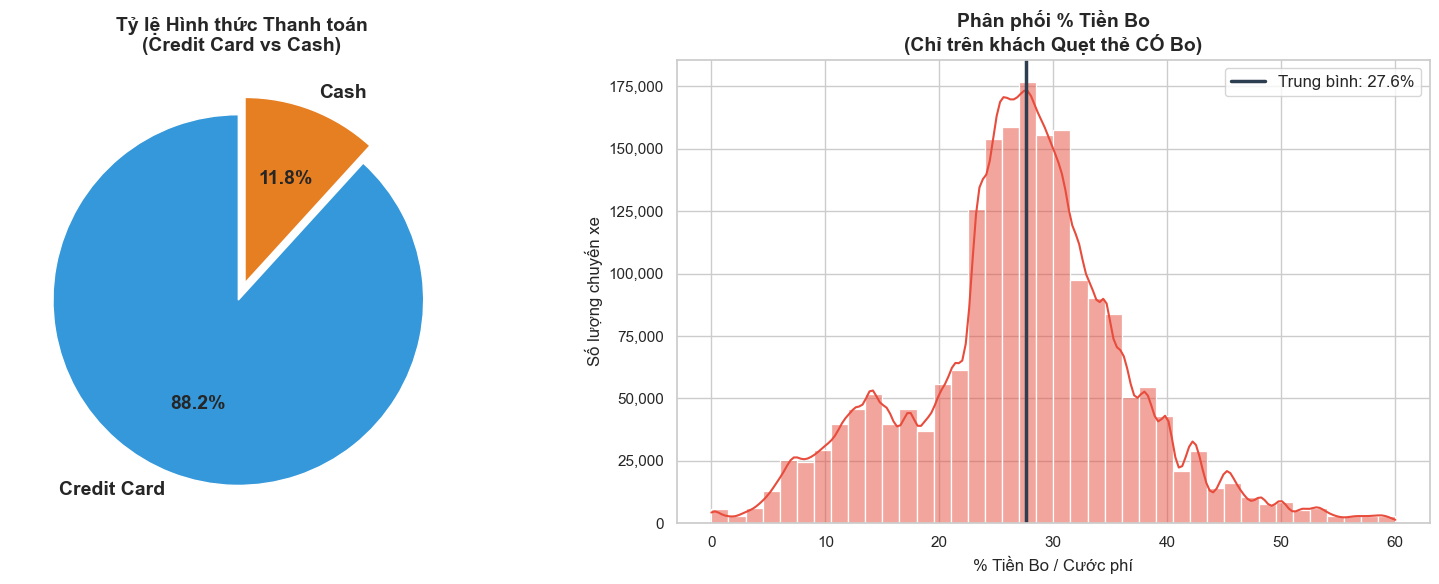

In [4]:
print("--- KHỐI 4 (BONUS): VĂN HÓA TIỀN BO & THANH TOÁN (TIPPING BEHAVIOR) ---")

# Map mã Payment Type thành tên dễ đọc
payment_map = {0: 'Flex Fare', 1: 'Credit Card', 2: 'Cash', 
               3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
df['payment_label'] = df['payment_type'].map(payment_map)

# 1. Tỷ lệ hình thức thanh toán
payment_counts = df['payment_label'].value_counts()
main_payments = payment_counts[payment_counts.index.isin(['Credit Card', 'Cash'])]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart Thanh toán
ax[0].pie(main_payments, labels=main_payments.index, autopct='%1.1f%%',
          colors=['#3498DB', '#E67E22'], startangle=90,
          textprops={'fontsize': 14, 'fontweight': 'bold'}, explode=(0.05, 0.05))
ax[0].set_title('Tỷ lệ Hình thức Thanh toán\n(Credit Card vs Cash)', fontsize=14, fontweight='bold')

# 2. Phân tích Tiền Bo (Chỉ trên tệp quẹt Thẻ)
card_trips = df[(df['payment_type'] == 1) & (df['tip_amount'] >= 0) & (df['fare_amount'] > 0)].copy()
card_trips['tip_pct'] = (card_trips['tip_amount'] / card_trips['fare_amount']) * 100
card_trips_with_tip = card_trips[card_trips['tip_pct'] <= 60]  # Lọc các giá trị nhiễu

# Tính phần trăm khách có Bo vs Không Bo
tip_zero = (card_trips['tip_amount'] == 0).sum() / len(card_trips) * 100
tip_nonzero = 100 - tip_zero
avg_tip_pct = card_trips[card_trips['tip_amount'] > 0]['tip_pct'].mean()

print(f"📊 Thống kê Tiền Bo (chỉ tính trên khách Quẹt thẻ):")
print(f"   - Tỷ lệ khách CÓ Bo:        {tip_nonzero:.1f}%")
print(f"   - Tỷ lệ khách KHÔNG Bo:     {tip_zero:.1f}%")
print(f"   - Mức Bo trung bình (khi có Bo): {avg_tip_pct:.1f}% trên giá cước\n")

# Histogram % Tiền Bo
sns.histplot(data=card_trips_with_tip[card_trips_with_tip['tip_pct'] > 0], 
             x='tip_pct', bins=40, color='#E74C3C', kde=True, ax=ax[1])
ax[1].axvline(avg_tip_pct, color='#2C3E50', linestyle='-', linewidth=2.5, 
              label=f'Trung bình: {avg_tip_pct:.1f}%')
ax[1].set_title('Phân phối % Tiền Bo\n(Chỉ trên khách Quẹt thẻ CÓ Bo)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('% Tiền Bo / Cước phí', fontsize=12)
ax[1].set_ylabel('Số lượng chuyến xe', fontsize=12)
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


> **📝 Góc nhìn Tiền đề Phân khúc (Segmentation Insights):**
>
> **1. Dân New York cực kỳ chuộng Quẹt thẻ (88.2%):**
> Chỉ có **11.8%** khách trả Tiền mặt. Điều này có nghĩa là hơn 88% dữ liệu Tip mà chúng ta phân tích là đáng tin cậy (không bị thiếu do tiền mặt không ghi nhận). Đây là một bộ dữ liệu về Tiền Bo cực kỳ phong phú và có thể tin tưởng để xây dựng Feature cho Segmentation.
>
> **2. Phát hiện "Bậc thang Tip Tâm lý" (Psychological Tip Anchoring):**
> Nhìn kỹ vào biểu đồ Histogram màu đỏ bên phải: Thay vì một đường cong trơn tru, bạn thấy có **nhiều đỉnh nhọn liên tiếp** ở mức ~20%, 25%, 28-30% đúng không? Đây không phải lỗi dữ liệu. Màn hình thanh toán của Taxi vàng NYC hiển thị **3 nút bấm Tip gợi ý sẵn** (thường là 20%, 25%, 30%). Khách hàng lười suy nghĩ nên phần lớn bấm vào một trong 3 nút đó thay vì tự nhập số! Đây gọi là **Hiệu ứng Neo tâm lý (Anchoring Effect)** - một khái niệm Behavioral Economics cực kỳ quan trọng.
>
> **3. Mức Bo trung bình 27.6% - "Sộp" hơn hẳn chuẩn thế giới:**
> Chuẩn Tip toàn cầu thường là 15-20%. Nhưng người New York Bo trung bình tới **27.6%** - chứng tỏ họ là tệp khách hàng chi tiêu hào phóng. Feature `tip_percentage` sẽ là một biến số cực kỳ đắt giá để phân chia thành Phân khúc "Khách VIP Sộp" (tip > 25%) và "Khách Bình dân" (tip < 15%) cho tuần sau.


# 5. Phân tích ma trận tương quan hành vi

--- KHỐI 5 (BONUS): MA TRẬN TƯƠNG QUAN HÀNH VI (BEHAVIORAL CORRELATION) ---


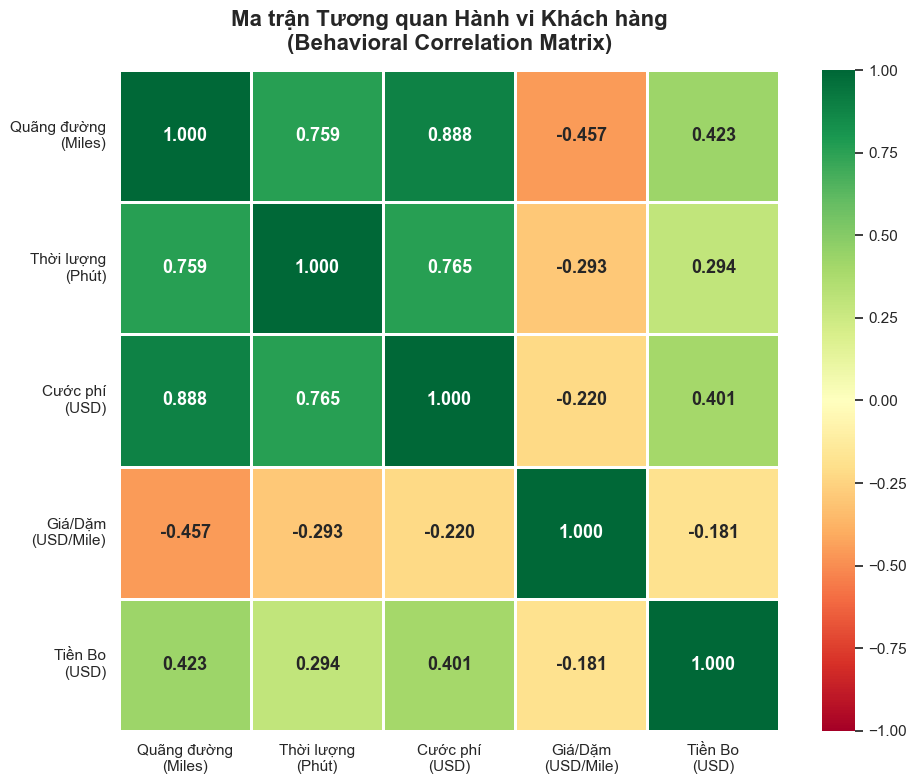


🔍 Các mối tương quan nổi bật:
   - Quãng đường & Cước phí:    r = 0.888
   - Quãng đường & Thời lượng:  r = 0.759
   - Giá/Dặm & Thời lượng:      r = -0.293
   - Tiền Bo & Cước phí:        r = 0.401


In [5]:
print("--- KHỐI 5 (BONUS): MA TRẬN TƯƠNG QUAN HÀNH VI (BEHAVIORAL CORRELATION) ---")

# 0. Tính lại các cột cần thiết trực tiếp trên df gốc (phòng trường hợp chưa tồn tại)
df['trip_duration_mins'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']

# 1. Lọc dữ liệu hợp lý để tính tương quan
behavior_cols = df[['trip_distance', 'trip_duration_mins', 'fare_amount', 
                     'fare_per_mile', 'tip_amount']].copy()

behavior_cols = behavior_cols[
    (behavior_cols['trip_distance'] > 0) &
    (behavior_cols['trip_duration_mins'] >= 1) &
    (behavior_cols['trip_duration_mins'] <= 120) &
    (behavior_cols['fare_amount'] > 0) &
    (behavior_cols['fare_per_mile'] > 0) &
    (behavior_cols['fare_per_mile'] < 50) &
    (behavior_cols['tip_amount'] >= 0)
].dropna()

# 2. Đổi tên cột cho dễ đọc
behavior_cols.columns = ['Quãng đường\n(Miles)', 'Thời lượng\n(Phút)', 
                          'Cước phí\n(USD)', 'Giá/Dặm\n(USD/Mile)', 'Tiền Bo\n(USD)']

# 3. Tính và vẽ ma trận tương quan
corr_matrix = behavior_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1,
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Ma trận Tương quan Hành vi Khách hàng\n(Behavioral Correlation Matrix)', 
          fontsize=16, fontweight='bold', pad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

# 4. In ra các cặp tương quan nổi bật
print("\n🔍 Các mối tương quan nổi bật:")
cm = corr_matrix.values
cols = ['Quãng đường\n(Miles)', 'Thời lượng\n(Phút)', 'Cước phí\n(USD)', 
        'Giá/Dặm\n(USD/Mile)', 'Tiền Bo\n(USD)']
print(f"   - Quãng đường & Cước phí:    r = {corr_matrix.iloc[0,2]:.3f}")
print(f"   - Quãng đường & Thời lượng:  r = {corr_matrix.iloc[0,1]:.3f}")
print(f"   - Giá/Dặm & Thời lượng:      r = {corr_matrix.iloc[3,1]:.3f}")
print(f"   - Tiền Bo & Cước phí:        r = {corr_matrix.iloc[4,2]:.3f}")


> **📝 Góc nhìn Feature Engineering (Tiền đề cho Segmentation):**
>
> **1. "Bộ Ba Thống trị" (The Big 3 - Màu xanh đậm ở góc trên trái):**
> Ba biến Quãng đường (0.888), Thời lượng (0.765) và Cước phí gần như đo lường cùng một thứ: "Độ lớn" của cuốc xe. Nếu dùng cả 3 để phân nhóm sẽ bị thừa và gây nhiễu (Multicollinearity). Chúng ta nên **chỉ chọn 1 trong 3** (Ưu tiên `trip_distance` vì nó khách quan, không bị ảnh hưởng bởi tắc đường).
>
> **2. Phát hiện "Nghịch lý Chặng ngắn - Giá đắt" (Màu cam - r = -0.457):**
> Tương quan âm giữa Quãng đường và Giá/Dặm chứng minh: **Càng đi xa thì giá mỗi dặm càng RẺ!** Cuốc xe ngắn 1-2 dặm phải gánh toàn bộ phí khởi hành cố định, đẩy Giá/Dặm lên rất cao. Đây là lý do khách đi sân bay (đường dài) được "hời" hơn về đơn giá so với khách nội đô. `fare_per_mile` sẽ là Feature đặc biệt để phân biệt 2 phân khúc này.
>
> **3. Tiền Bo tỷ lệ thuận với Quãng đường (r = 0.423):**
> Khách đi càng xa thì tổng số tiền Bo càng nhiều (tính theo USD tuyệt đối). Tuy nhiên tương quan ở mức trung bình (0.423), không phải tuyệt đối, ngụ ý còn các yếu tố khác (Thời gian đêm, khu vực đón/trả) cũng ảnh hưởng đến hành vi Bo của khách.


# 6. Phân tích số lượng khách hàng

--- KHỐI 6 (BONUS): PHÂN TÍCH SỐ LƯỢNG HÀNH KHÁCH (PASSENGER COUNT) ---


C:\Users\minhh\AppData\Local\Temp\ipykernel_42908\85776914.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pax_counts, x='Số hành khách', y='Số lượng chuyến', ax=ax[0], palette='Blues_r')
C:\Users\minhh\AppData\Local\Temp\ipykernel_42908\85776914.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_by_pax, x='Số hành khách', y='Quãng đường TB (Miles)',


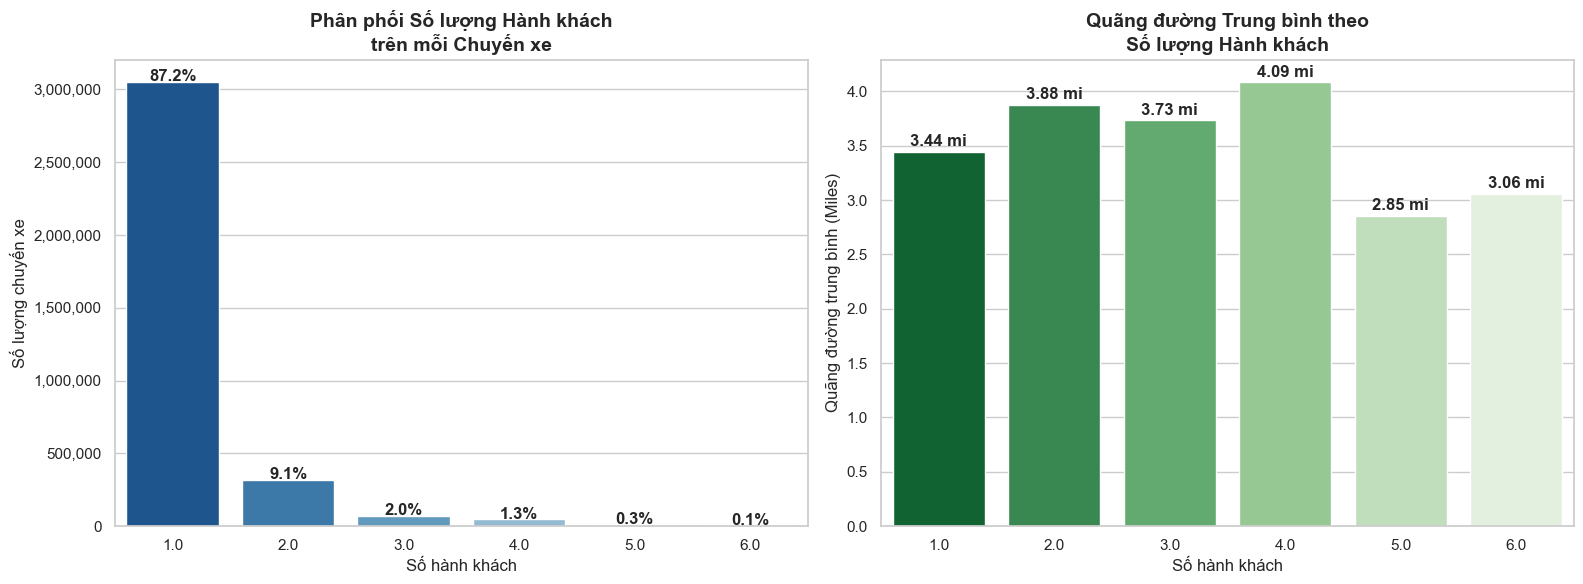

In [6]:
print("--- KHỐI 6 (BONUS): PHÂN TÍCH SỐ LƯỢNG HÀNH KHÁCH (PASSENGER COUNT) ---")

pax_df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)].copy()

pax_counts = pax_df['passenger_count'].value_counts().sort_index().reset_index()
pax_counts.columns = ['Số hành khách', 'Số lượng chuyến']
pax_counts['Tỷ lệ (%)'] = (pax_counts['Số lượng chuyến'] / pax_counts['Số lượng chuyến'].sum() * 100).round(1)

# Quãng đường trung bình theo nhóm
dist_by_pax = pax_df[pax_df['trip_distance'] > 0].groupby('passenger_count')['trip_distance'].mean().reset_index()
dist_by_pax.columns = ['Số hành khách', 'Quãng đường TB (Miles)']

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ trái: Phân phối số lượng hành khách
sns.barplot(data=pax_counts, x='Số hành khách', y='Số lượng chuyến', ax=ax[0], palette='Blues_r')
ax[0].set_title('Phân phối Số lượng Hành khách\ntrên mỗi Chuyến xe', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Số hành khách', fontsize=12)
ax[0].set_ylabel('Số lượng chuyến xe', fontsize=12)
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
for i, row in pax_counts.iterrows():
    ax[0].text(i, row['Số lượng chuyến'] + 5000, f"{row['Tỷ lệ (%)']:.1f}%",
               ha='center', fontweight='bold', fontsize=12)

# Biểu đồ phải: Quãng đường TB theo số lượng hành khách
sns.barplot(data=dist_by_pax, x='Số hành khách', y='Quãng đường TB (Miles)', 
            ax=ax[1], palette='Greens_r')
ax[1].set_title('Quãng đường Trung bình theo\nSố lượng Hành khách', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Số hành khách', fontsize=12)
ax[1].set_ylabel('Quãng đường trung bình (Miles)', fontsize=12)
for i, row in dist_by_pax.iterrows():
    ax[1].text(i, row['Quãng đường TB (Miles)'] + 0.05,
               f"{row['Quãng đường TB (Miles)']:.2f} mi",
               ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


> **📝 Góc nhìn Hành vi Nhóm (Group Behavior Insights):**
>
> **1. Taxi vàng là "Xe cá nhân" chứ không phải "Xe cộng đồng" (87.2% đi một mình):**
> Tỷ lệ áp đảo cho thấy khách hàng cốt lõi của Taxi vàng là dân văn phòng, doanh nhân đi đơn lẻ - họ coi Taxi là không gian riêng tư, không phải phương tiện đi ghép tập thể. Phân khúc **"Solo Rider"** phải là trọng tâm số 1 của mọi chiến dịch Khuyến mãi.
>
> **2. Nhóm nhỏ (2-4 người) đi XA hơn người đi đơn - Dấu hiệu của "Đi chơi/Đi ăn nhóm":**
> Quãng đường tăng dần từ 1 người (3.44 mi) → đạt đỉnh ở nhóm 4 người (4.09 mi). Điều này gợi ý rằng nhóm 2-4 người thường không phải đang đi làm mà đang **đi ăn, đi tiệc hoặc đi sân bay theo nhóm** - những cuốc xe có quãng đường dài hơn cuốc đi làm thông thường.
>
> **3. Nhóm lớn (5-6 người) lại đi ngắn hơn - Nghịch lý thú vị:**
> Nhóm 5-6 người lại chỉ đi 2.85-3.06 miles (ngắn hơn cả người đi một mình!). Lý giải hợp lý nhất: Nhóm đông người thường di chuyển **trong nội khu** (đến nhà hàng gần đó, đi từ khách sạn đến điểm tham quan gần)  - vì việc tìm một chiếc Taxi vừa đủ 5-6 chỗ ngồi ở Manhattan vốn đã rất hiếm nên họ không đi xa.
